In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.visualization import ImageNormalize, LinearStretch, ZScaleInterval

In [2]:

gal = "storm_2"
base_path = f"/home/otteleno/fall/fall_data/{gal}"

FOLDER_1 = f"{base_path}/{gal}_25_2000/{gal}_25_2000_mf/"
FOLDER_2 = f"{base_path}/{gal}_25_4000/{gal}_25_4000_mf/"
FOLDER_3 = f"{base_path}/{gal}_26p5_2000/{gal}_26p5_2000_mf/"
FOLDER_4 = f"{base_path}/{gal}_26p5_4000/{gal}_26p5_4000_mf/"

FOLDERS = [FOLDER_1, FOLDER_2, FOLDER_3, FOLDER_4]
FILES_PER_FOLDER = 3
CMAP = "gray"  # try "viridis", "magma", "inferno", ...
FIGSIZE = (12, 15)

FITS_SUFFIXES = (
    ".fits", 
)

In [3]:
def find_fits_files(folder, n):
    """Return the first `n` FITS files (sorted by name) in `folder`."""
    folder = Path(folder)
    if not folder.is_dir():
        raise FileNotFoundError(f"Folder not found: {folder}")
    files = sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.name.lower().endswith(FITS_SUFFIXES)
    )
    return files[:n]


def load_image(path):
    """Load the first HDU containing image data (2D or higher) as a 2D float array.

    If the data has more than 2 dimensions (e.g. a data cube), the first
    slice along each leading axis is used.
    """
    with fits.open(path) as hdul:
        for hdu in hdul:
            data = getattr(hdu, "data", None)
            if data is None or getattr(data, "ndim", 0) < 2:
                continue  # skip empty HDUs and tables
            data = np.array(data, dtype=float)  # copy while the file is open
            while data.ndim > 2:
                data = data[0]
            return data
    raise ValueError("no image data found")


def show_image(ax, data):
    """Draw a 2D array using a zscale (astronomy-standard) contrast stretch."""
    if not np.isfinite(data).any():
        raise ValueError("image contains only NaN/inf values")
    norm = ImageNormalize(data, interval=ZScaleInterval(), stretch=LinearStretch())
    ax.imshow(data, cmap=CMAP, norm=norm, origin="lower")  # FITS origin = bottom-left

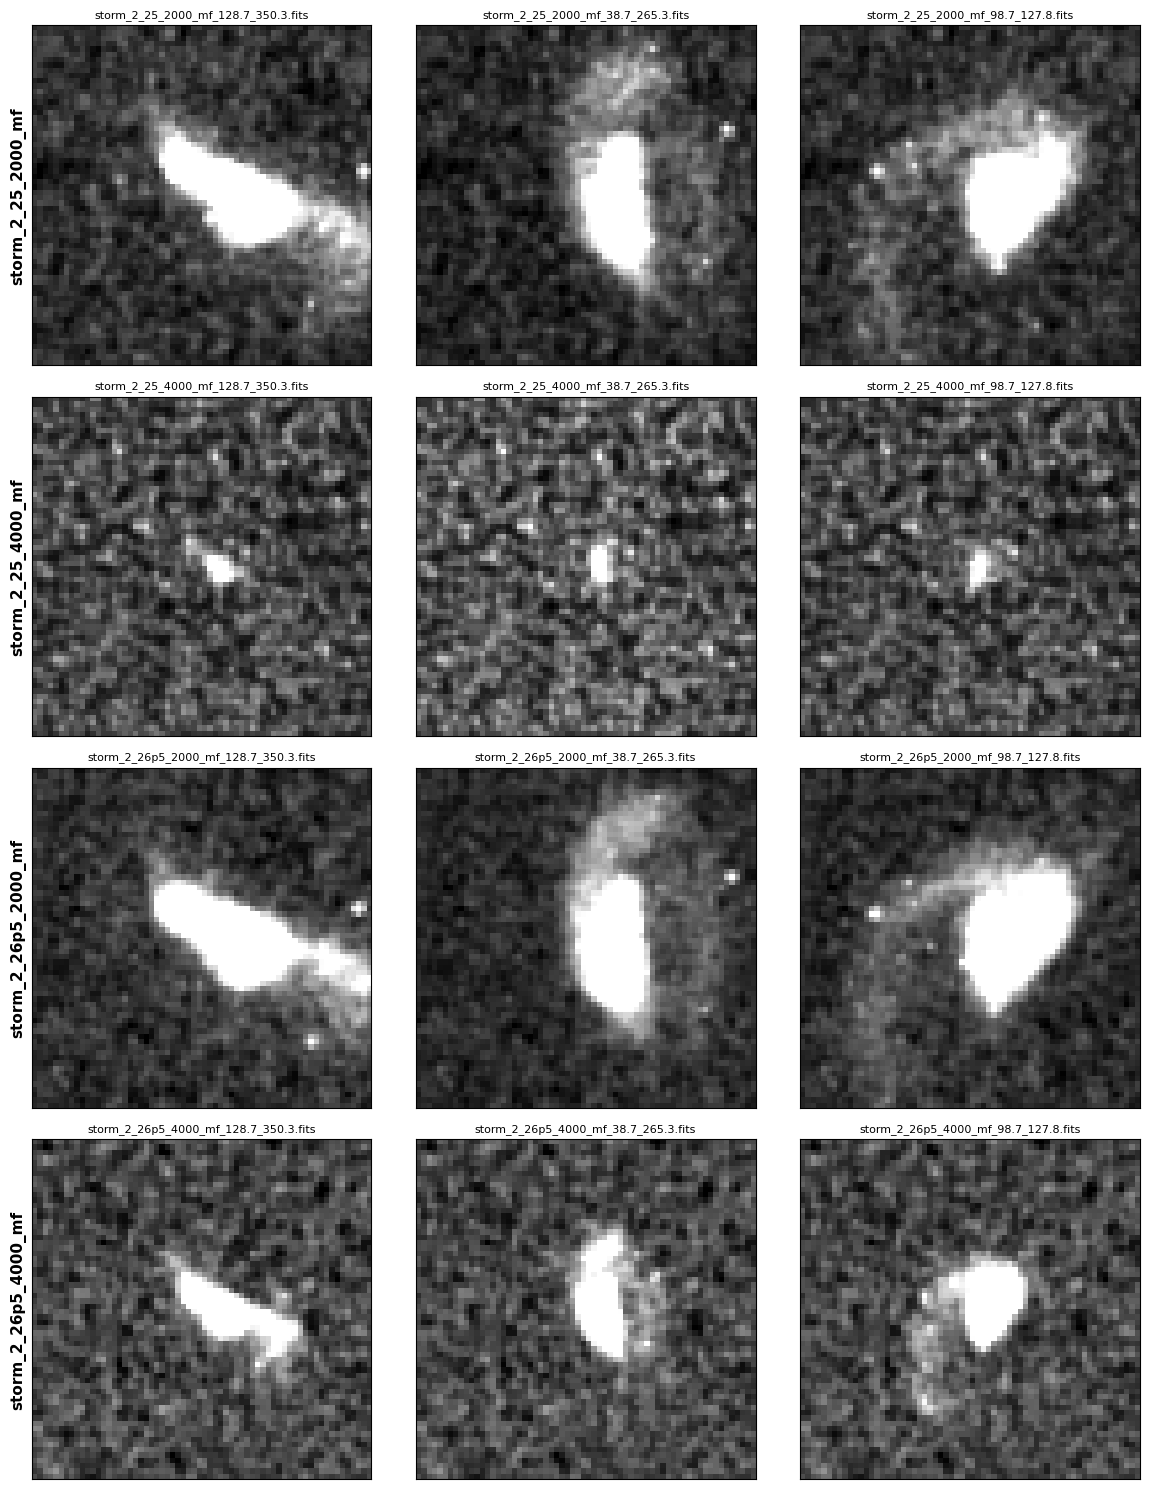

In [8]:
n_rows, n_cols = len(FOLDERS), FILES_PER_FOLDER
fig, axes = plt.subplots(n_rows, n_cols, figsize=FIGSIZE, squeeze=False)

for r, folder in enumerate(FOLDERS):
    try:
        files = find_fits_files(folder, n_cols)
    except FileNotFoundError as err:
        print(err)
        files = []

    for c in range(n_cols):
        ax = axes[r][c]
        ax.set_xticks([])
        ax.set_yticks([])

        # Row label = folder name (left-most column only)
        if c == 0:
            ax.set_ylabel(Path(folder).name, fontsize=11, fontweight="bold")

        if c >= len(files):
            ax.text(0.5, 0.5, "no file", ha="center", va="center",
                    transform=ax.transAxes, color="gray_r")
            continue

        path = files[c]
        ax.set_title(path.name, fontsize=8)
        try:
            show_image(ax, load_image(path))
        except Exception as err:  # keep going if one file is bad
            ax.text(0.5, 0.5, f"Can't display:\n{err}", ha="center",
                    va="center", transform=ax.transAxes,
                    fontsize=8, color="red", wrap=True)

fig.tight_layout()
plt.show()